In [ ]:
# Importing preliminary & fundemental Python packages for machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Connecting/mounting the Google Colaboratory notebook to my Google Drive to access and modify files/folders
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Reading the JSON file provided within the dataset folder for the labels of each video
metadata = pd.read_json('/content/gdrive/MyDrive/DeepfakeDetection/deepfake-detection-challenge/train_sample_videos').T

# Removing the last column, since it is of no use in this project
metadata = metadata.iloc[:,:-1]

# Presenting the JSON file in a table format
metadata.head()

In [ ]:
# Choosing an example video
video_file = '/content/gdrive/MyDrive/DeepfakeDetection/deepfake-detection-challenge/train_sample_videos/train_video_000.mp4'

# Setting up CV2
capture = cv.VideoCapture(video_file)
success, image = capture.read()

print('{} {}'.format(success, image))

capture.release()   

# Presenting the image
fig, ax = plt.subplots(1,1, figsize=(15, 15))
ax.imshow(image)

In [ ]:
# Importing face_recognition to identify and crop each image to the appropriate face within it
import face_recognition
from PIL import Image

In [ ]:
# Recognize faces in the image
pad = 100

# Saving the various face locations within the image. Often it is only one face.
face_locations=face_recognition.face_locations(image)
print(face_locations)

for face_location in face_locations:
    # Print the location of each face in this image
    top, right, bottom, left = face_location
    print('Pixel Location Top: {}, Bottom: {}, Left: {}, Right: {}'.format(top, bottom, left, right))
    
    # Edit and crop the image to include mainly the human face
    face_image = image[top:bottom, left:right]

    # Presenting that image
    fig, ax = plt.subplots(1,1, figsize=(5, 5))
    plt.grid(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.imshow(face_image)


print('Successful')

In [ ]:
# From each video, we want 10 frames. Each video has 300, so 300/10=30. We save each 30th frame.
limited=[29,59,89,119,149,179,209,239,269,299]

j=0
fake_image_num=0
real_image_num=0

fig, ax = plt.subplots(1,1, figsize=(5, 5))
plt.grid(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Looping through all 400 training videos
for i in range(0,400):

    status = metadata.iloc[i][0]
    cap= cv.VideoCapture('/content/gdrive/MyDrive/DeepfakeDetection/deepfake-detection-challenge/train_sample_videos/train_video_'+str(i).zfill(3)+'.mp4')
    path='/content/gdrive/MyDrive/DeepfakeDetection/Dataset/'+str(status)
    print('Video'+str(i).zfill(3)+'----------------------------------------------------------------')
    while(cap.isOpened()):
        ret, frame = cap.read()
        if ret == False:
            break
        
        if j in limited:
            ''' Within the lines below, the same process applied in
            the cell above is applied to all 10 image frames savedfor each image '''

            face_locations=face_recognition.face_locations(frame)
            print(face_locations)

            for face_location in face_locations:

                # Print the location of each face in this image
                top, right, bottom, left = face_location
                print(str(j) ': a face is located at pixel location Top: {}, Left: {}, Bottom: {}, Right: {}'.format(top, left, bottom, right))

                # Access the actual face itself:
                face_image = frame[top:bottom, left:right]
                ax.imshow(face_image)

            if str(status) == 'FAKE':
                cv.imwrite(os.path.join(path , 'frame'+str(fake_image_num)+'.jpg'), face_image)
                fake_image_num+=1
            else:
                cv.imwrite(os.path.join(path , 'frame'+str(real_image_num)+'.jpg'), face_image)
                real_image_num+=1   
        
        j+=1
    
    print(j)
    j = 0
    
    # Captured content is released and the capturer instance is discarded
    cap.release()
    cv.destroyAllWindows()

In [ ]:
# Importing ImageDataGenerator for the loading and seperation of data as training and validation
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Declaring variables that will be used in the following steps
IMG_HEIGHT = 233
IMG_WIDTH = IMG_HEIGHT
BATCH_SIZE = 32
INPUT_SHAPE = [IMG_HEIGHT,IMG_WIDTH,3]

''' Image data generator is used for efficiency in obtaining data from folder directory,
and augmenting it using different image transformation techniques. '''
data_gen = ImageDataGenerator(
                        rotation_range=40,
                        width_shift_range=0.2,
                        height_shift_range=0.2,
                        brightness_range=(0.2,0.8),
                        shear_range=0.2,
                        zoom_range=0.2,
                        channel_shift_range=0.0,
                        fill_mode='nearest',
                        horizontal_flip=True,
                        vertical_flip=True,
                        rescale=1./255,
                        validation_split=0.2)

# Dataset directory
dataset = '/content/gdrive/MyDrive/DeepfakeDetection/Dataset'

# Obtaining training image data from dataset directory
training = data_gen.flow_from_directory(
                                    dataset,
                                    target_size=(IMG_HEIGHT, IMG_WIDTH),
                                    batch_size=BATCH_SIZE,
                                    class_mode='binary',
                                    subset='training')

# Obtaining validation image data from dataset directory
validation = data_gen.flow_from_directory(
    dataset,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation')

Found 3190 images belonging to 2 classes.
Found 797 images belonging to 2 classes.


In [ ]:
# Importing the necessary components/layers for the convolutional neural network

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers import SGD

from tensorflow.keras.metrics import AUC

In [ ]:
# Initializing, customizing, and compiling CNN model

cnn = Sequential()

cnn.add(Conv2D(filters=32, kernel_size=7, activation='relu', input_shape=INPUT_SHAPE))
cnn.add(MaxPool2D(pool_size=2, strides=1))
cnn.add(Conv2D(filters=16, kernel_size=3, activation='relu', input_shape=INPUT_SHAPE))
cnn.add(MaxPool2D(pool_size=2, strides=2))
cnn.add(Flatten())
cnn.add(Dense(units=16, activation='relu'))
cnn.add(Dense(units=1, activation='sigmoid'))

opt = SGD(learning_rate=0.0000001)
cnn.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy', AUC()])

In [ ]:
# Creating a model history logger to save results
filename='CNNResults.csv'
history_logger=tf.keras.callbacks.CSVLogger(filename, separator=',', append=True)

In [ ]:
# Training and validating CNN using training and validation data
history = cnn.fit(x=training, validation_data=validation, batch_size=BATCH_SIZE, epochs=20, callbacks=[history_logger])

Epoch 1/20
100/100 [==============================] - 595s 6s/step - loss: 0.6804 - accuracy: 0.7831 - auc: 0.4843 - val_loss: 0.6797 - val_accuracy: 0.7754 - val_auc: 0.5058
Epoch 2/20
100/100 [==============================] - 82s 825ms/step - loss: 0.6802 - accuracy: 0.7812 - auc: 0.4972 - val_loss: 0.6797 - val_accuracy: 0.7867 - val_auc: 0.5026
Epoch 3/20
100/100 [==============================] - 82s 822ms/step - loss: 0.6800 - accuracy: 0.7890 - auc: 0.4930 - val_loss: 0.6789 - val_accuracy: 0.7779 - val_auc: 0.4732
Epoch 4/20
100/100 [==============================] - 81s 809ms/step - loss: 0.6793 - accuracy: 0.7878 - auc: 0.4931 - val_loss: 0.6781 - val_accuracy: 0.7867 - val_auc: 0.5097
Epoch 5/20
100/100 [==============================] - 80s 803ms/step - loss: 0.6787 - accuracy: 0.7915 - auc: 0.5056 - val_loss: 0.6780 - val_accuracy: 0.7867 - val_auc: 0.5100
Epoch 6/20
100/100 [==============================] - 81s 809ms/step - loss: 0.6782 - accuracy: 0.7915 - auc: 0.4971 

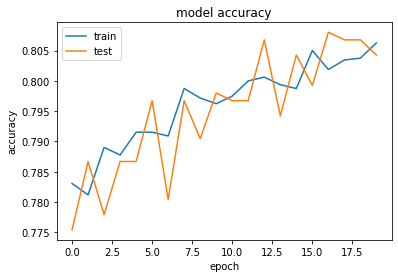

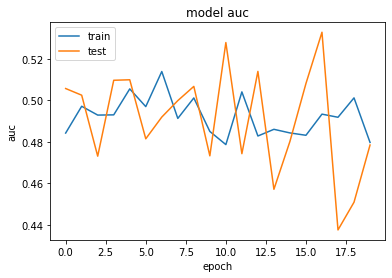

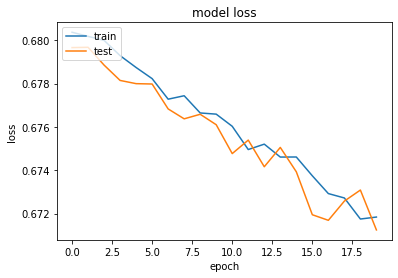

In [ ]:
# To plot a graph representing the accuracy of the model per epoch 
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# To plot a graph representing the AUC score of the model per epoch 
plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])
plt.title('model auc')
plt.ylabel('auc')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# To plot a graph representing the loss of the model per epoch
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()